In [1]:
#Step 0: Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.utils import resample

In [2]:
#Step 1:Load data
df_raw = pd.read_excel('../data/Concrete_Data.xls')
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)  

In [3]:
df_raw.sample(10, random_state=2025)

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
565,295.80,0.00,0.00,185.70,0.00,1091.4,769.30,7,14.843729
690,288.00,192.00,0.00,192.00,0.00,932.0,717.80,7,23.523542
636,300.00,0.00,0.00,184.00,0.00,1075.0,795.00,28,26.848195
43,380.00,0.00,0.00,228.00,0.00,932.0,670.00,180,53.104131
720,203.50,305.30,0.00,203.50,0.00,963.4,630.00,90,51.863764
346,213.74,0.00,174.74,154.79,10.16,1053.5,776.35,28,40.148187
149,425.00,106.30,0.00,153.50,16.50,852.1,887.10,56,64.300532
376,376.00,0.00,0.00,214.60,0.00,1003.5,762.36,28,31.971002
605,236.00,0.00,0.00,194.00,0.00,968.0,885.00,3,6.467285
436,172.38,13.61,172.37,156.76,4.14,1006.3,856.40,28,33.687797


In [4]:
#Step 2: Preprocessing
df_baking = df_raw.copy()
df_baking.columns = (
    [
     'cement',
     'blast_furnance_slag',
     'fly_ash',
     'water',
     'superplasticizer',
     'coarse_aggregate',
     'fine_aggregate',
     'age',
     'compressive_strength'
     ]
)
df_baking['log_age'] = df_baking['age'].apply(lambda x: np.log(x))
df_baking = df_baking.drop(columns=['age'])
df = df_baking.copy()

In [5]:
df_train, df_test = train_test_split(df, test_size=0.1, random_state=2025)
df_train, df_val = train_test_split(df_train, test_size=0.15, random_state=2025)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [6]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
cement,787.0,277.511995,103.645635,102.000000,190.340000,260.000000,349.000000,540.000000
blast_furnance_slag,787.0,76.006582,87.306962,0.000000,0.000000,24.000000,145.000000,359.400000
fly_ash,787.0,52.621970,63.618010,0.000000,0.000000,0.000000,118.215000,200.100000
water,787.0,181.943329,21.491940,121.750000,164.900000,185.700000,192.350000,246.900000
superplasticizer,787.0,5.981700,5.856357,0.000000,0.000000,6.000000,10.000000,32.200000
coarse_aggregate,787.0,973.460280,75.675481,801.000000,932.000000,968.000000,1028.400000,1145.000000
fine_aggregate,787.0,774.304015,79.635527,594.000000,734.000000,780.090000,825.000000,992.600000
compressive_strength,787.0,35.096923,16.585314,2.331808,23.581704,33.398217,44.391912,82.599225
log_age,787.0,3.139099,1.190561,0.000000,1.945910,3.332205,4.025352,5.899897


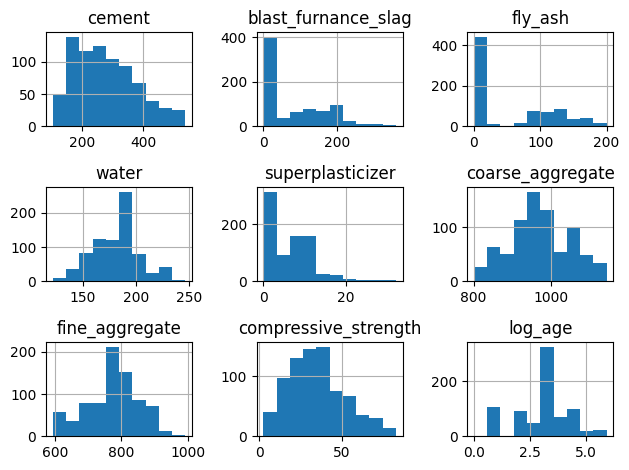

In [7]:
df_train.hist()
plt.tight_layout()
plt.show()

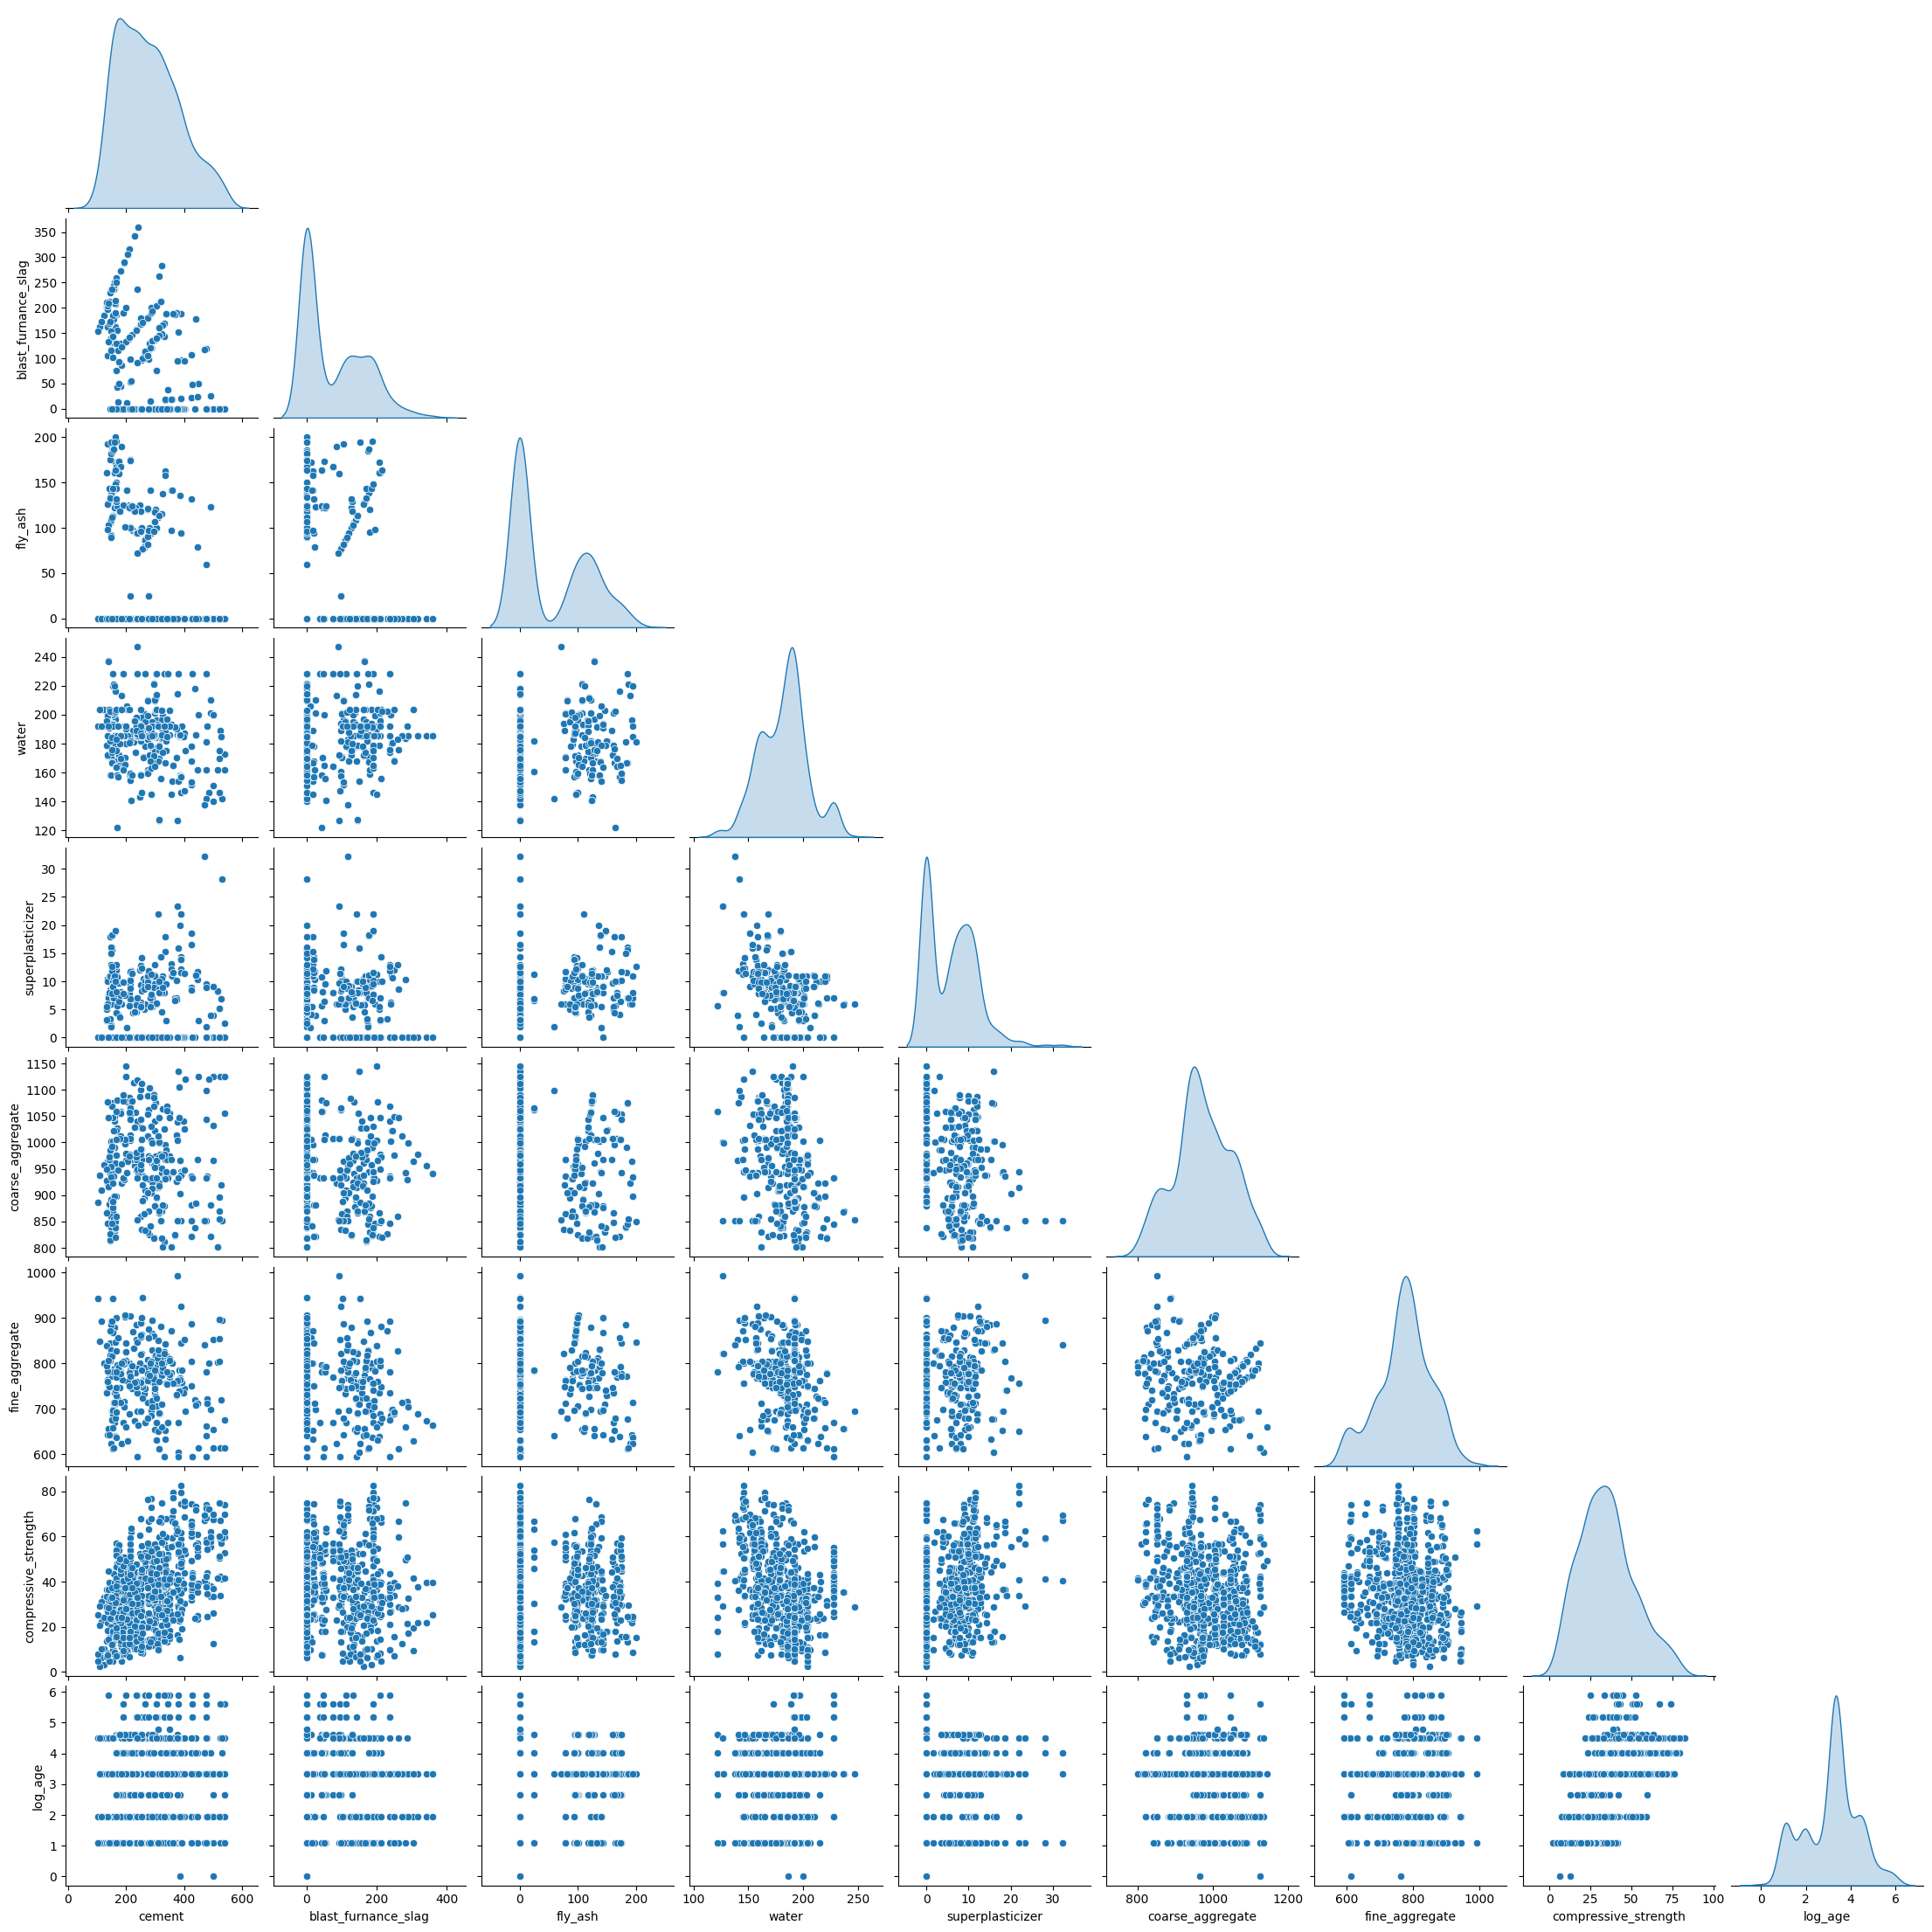

In [8]:
sns.pairplot(df_train, diag_kind='kde', corner=True)
plt.show()


In [9]:
df_train.corr()

,cement,blast_furnance_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,compressive_strength,log_age
cement,1.000000,-0.290142,-0.392565,-0.067864,0.080171,-0.133348,-0.210930,0.477788,-0.005543
blast_furnance_slag,-0.290142,1.000000,-0.303220,0.110267,0.044210,-0.295844,-0.296009,0.139113,-0.012718
fly_ash,-0.392565,-0.303220,1.000000,-0.270643,0.399970,0.015989,0.063410,-0.067576,0.018036
water,-0.067864,0.110267,-0.270643,1.000000,-0.640902,-0.208677,-0.454010,-0.296369,0.137722
superplasticizer,0.080171,0.044210,0.399970,-0.640902,1.000000,-0.237988,0.192984,0.386070,-0.012233
coarse_aggregate,-0.133348,-0.295844,0.015989,-0.208677,-0.237988,1.000000,-0.131032,-0.198970,-0.067842
fine_aggregate,-0.210930,-0.296009,0.063410,-0.454010,0.192984,-0.131032,1.000000,-0.154947,-0.106039
compressive_strength,0.477788,0.139113,-0.067576,-0.296369,0.386070,-0.198970,-0.154947,1.000000,0.569114
log_age,-0.005543,-0.012718,0.018036,0.137722,-0.012233,-0.067842,-0.106039,0.569114,1.000000


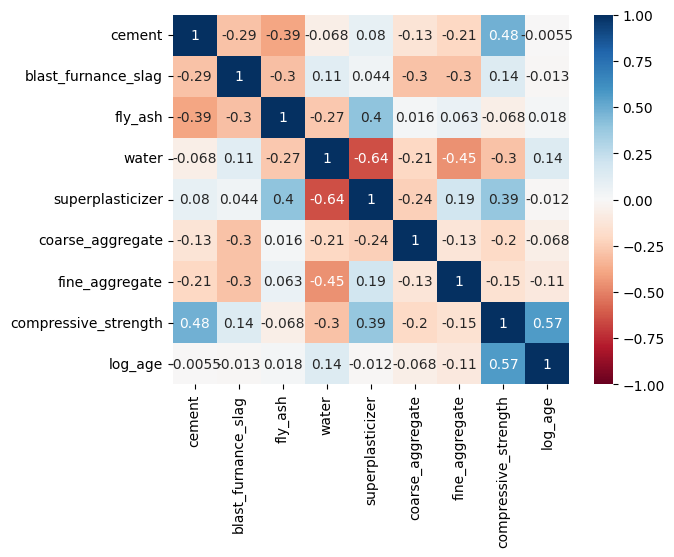

In [10]:
sns.heatmap(data=df_train.corr(), vmin=-1, vmax=1, cmap='RdBu', annot=True)
plt.show()

In [11]:
#Step 4:ML
X_train = df_train.drop(columns='compressive_strength')
y_train = df_train['compressive_strength']

X_val = df_val.drop(columns='compressive_strength')
y_val = df_val['compressive_strength']

X_test = df_test.drop(columns='compressive_strength')
y_test = df_test['compressive_strength']



In [12]:
#Pipeline
reg_knn = Pipeline([
    ('proc', MinMaxScaler()),
    ('knn', KNeighborsRegressor())
])

reg_knn.fit(X_train, y_train)

,steps,"[('proc', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [13]:
y_hat = reg_knn.predict(X_val)
print(f'RMSE: {np.sqrt(mean_squared_error(y_val, y_hat)):.2f}')
print(f'R2: {(r2_score(y_val, y_hat)):.2f}')

RMSE: 7.34
R2: 0.82


In [14]:
reg_knn_cv = GridSearchCV(
    reg_knn,
    param_grid={
        'knn__n_neighbors': [3,5,7,9,11,13,15,17,19,21]
    },
    cv=5
)

reg_knn_cv.fit(X_train, y_train)

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'knn__n_neighbors': [3, 5, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,feature_range,"(0, ...)"


In [15]:
y_hat = reg_knn_cv.best_params_


In [16]:
y_hat = reg_knn_cv.predict(X_val)
print(f'RMSE: {np.sqrt(mean_squared_error(y_val, y_hat)):.2f}')
print(f'R2: {(r2_score(y_val, y_hat)):.2f}')

RMSE: 6.68
R2: 0.85


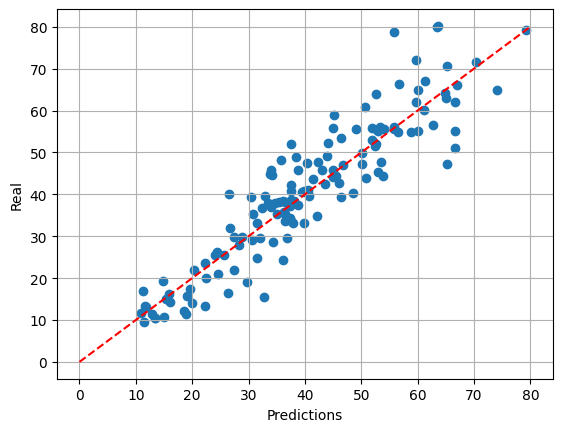

In [17]:
plt.scatter(y_hat, y=y_val)
plt.grid(True)
plt.xlabel('Predictions')
plt.ylabel('Real')
plt.plot([0,80], [0,80], c='r', linestyle='--')
plt.show()

In [18]:
clf_tree = Pipeline([
    ('proc', MinMaxScaler()),
    ('tree', DecisionTreeRegressor(max_depth=6,random_state=2025))
])

clf_rf = Pipeline([
    ('proc', MinMaxScaler()),
    ('rf', RandomForestRegressor(random_state=2025))
])

clf_hb = Pipeline([
    ('proc', MinMaxScaler()),
    ('hb', HistGradientBoostingRegressor(random_state=2025))
])


In [19]:
param_grids = {
    'tree':{
        'tree__max_depth':[2,4,5,6,7],
        'tree__min_samples_split':[2,4,6],
    },
    'rf':{
        'rf__max_depth':[2,4,5,6,7],
        'rf__min_samples_split':[2,4,6],
        'rf__n_estimators':[50,100,150,200]
    },
    'hb':{
        'hb__max_depth':[2,4,5,6,7]
    }
}

models = [
          (clf_tree,'Decission Tree', 'tree'),
          (clf_rf,'Random Forest', 'rf'),
          (clf_hb,'Histogram GBoosting', 'hb')
]

performance = {}
for est, name, sname in models:
  est.fit(X_train, y_train)
  estimator_cv = GridSearchCV(
      est,
      param_grid = param_grids[sname],
      cv = 5
  )
  estimator_cv.fit(X_train, y_train)
  y_hat = estimator_cv.predict(X_val)
  mse = mean_squared_error(y_val, y_hat)
  r2 = round(r2_score(y_val, y_hat), 2)
  best_params = estimator_cv.best_params_
  performance[name] = {
      'MSE': mse,
      'RMSE': np.sqrt(mse),
      'R2 Score': r2,
      'Best Params': best_params,
      'estimator': estimator_cv.best_estimator_
  }


In [20]:
df_models = pd.DataFrame(performance)
display(df_models.T)

,MSE,RMSE,R2 Score,Best Params,estimator
Decission Tree,75.67768,8.699292,0.74,"{'tree__max_depth': 7, 'tree__min_samples_spli...","(MinMaxScaler(), DecisionTreeRegressor(max_dep..."
Random Forest,36.834796,6.069168,0.87,"{'rf__max_depth': 7, 'rf__min_samples_split': ...","(MinMaxScaler(), (DecisionTreeRegressor(max_de..."
Histogram GBoosting,23.818152,4.880384,0.92,{'hb__max_depth': 7},"(MinMaxScaler(), HistGradientBoostingRegressor..."


In [21]:
tree_reg_cv = DecisionTreeRegressor(max_depth=7, min_samples_split=6)
rforest_reg_cv = RandomForestRegressor(max_depth=7, n_estimators=200,random_state=2025)
hb_reg_cv = HistGradientBoostingRegressor(max_depth=7)

tree_reg_cv.fit(X_train,y_train)
rforest_reg_cv.fit(X_train,y_train)
hb_reg_cv.fit(X_train,y_train)

y_hat1 = tree_reg_cv.predict(X_val)
y_hat2 = rforest_reg_cv.predict(X_val)
y_hat3 = hb_reg_cv.predict(X_val)



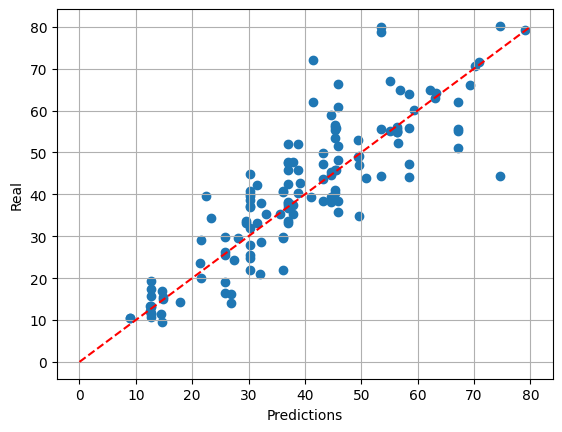

In [22]:
plt.scatter(y_hat1, y=y_val)
plt.grid(True)
plt.xlabel('Predictions')
plt.ylabel('Real')
plt.plot([0,80], [0,80], c='r', linestyle='--')
plt.show()

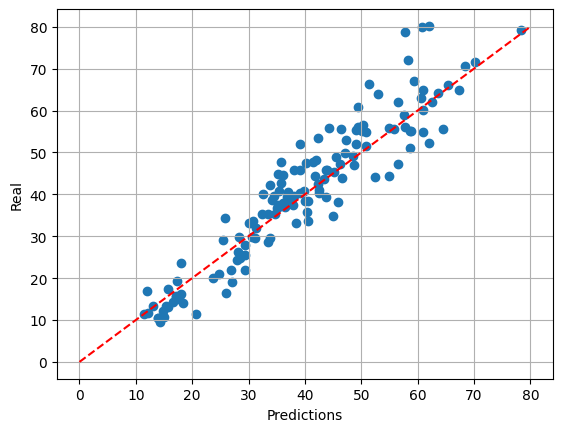

In [23]:
plt.scatter(y_hat2, y=y_val)
plt.grid(True)
plt.xlabel('Predictions')
plt.ylabel('Real')
plt.plot([0,80], [0,80], c='r', linestyle='--')
plt.show()

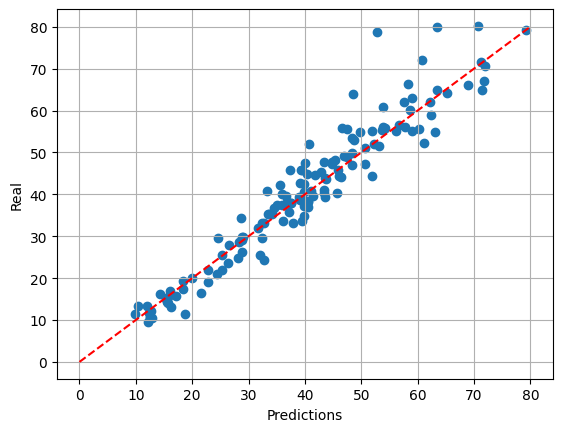

In [24]:
plt.scatter(y_hat3, y=y_val)
plt.grid(True)
plt.xlabel('Predictions')
plt.ylabel('Real')
plt.plot([0,80], [0,80], c='r', linestyle='--')
plt.show()

In [25]:
n_iterations = 50
mse_score = []
rmse_scores = []
r2_scores = []

for i in range(n_iterations):
  df_rs = resample(df_train)
  X_train_rs = df_rs.drop(columns='compressive_strength')
  y_train_rs = df_rs['compressive_strength']

  X_train_rs = X_train.reset_index(drop=True)
  y_train_rs = y_train.reset_index(drop=True)

  hb_reg_cv.fit(X_train_rs, y_train_rs)

  y_hat = hb_reg_cv.predict(X_test)

  mse = round(mean_squared_error(y_test, y_hat), 2)
  rmse = np.sqrt(mse)
  r2 = round(r2_score(y_test,y_hat),2)

  mse_scores.append(mse)
  rmse_scores.append(rmse)
  r2_scores.append(r2)





NameError: name 'mse_scores' is not defined